# GNN_training

In [1]:
# Imports principaux pour tout le notebook
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score

import networkx as nx
import xarray as xr

# Chemin du graphe : même dossier que le notebook (après pull) ou chemin serveur
base_dir = Path(".").resolve()
graph_path = base_dir / "graph_focus_zone.pkl"  # JAN
if not graph_path.exists():
    graph_path = Path("/users/eleves-b/2023/marc.saade/bachelor-thesis/thesis") / "graph_focus_zone.pkl"

print("Loading graph from:", graph_path)
with open(graph_path, "rb") as f:
    G = pickle.load(f)

print(f"G: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Nombre de "branchements" (nœuds avec plus d'un arc sortant)
out_deg = dict(G.out_degree())
branching_nodes = [n for n in G.nodes() if out_deg.get(n, 0) > 1]
print(f"Nœuds avec au moins 2 arcs sortants (branchements): {len(branching_nodes):,}")

Loading graph from: /users/eleves-b/2023/marc.saade/bachelor-thesis/thesis/graph_focus_zone.pkl
G: 623,661 nodes, 1,250,088 edges
Nœuds avec au moins 2 arcs sortants (branchements): 294,182


In [2]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

MAX_SEGMENT_KM = 200.0  # seuil pour couper les sauts non physiques (comme traverser la Floride)

to_remove = []
for u, v in G.edges():
    lat1, lon1 = G.nodes[u]["lat"], G.nodes[u]["lon"]
    lat2, lon2 = G.nodes[v]["lat"], G.nodes[v]["lon"]
    seg_dist = haversine_km(lat1, lon1, lat2, lon2)
    if seg_dist > MAX_SEGMENT_KM:
        to_remove.append((u, v))

print(f"Removing {len(to_remove):,} edges with segment distance > {MAX_SEGMENT_KM} km")
G.remove_edges_from(to_remove)
print(f"Remaining edges: {G.number_of_edges():,}")

# Garder UNIQUEMENT la plus grande composante connexe -> tout couple de nœuds a un chemin
wcc = list(nx.weakly_connected_components(G))
largest = max(wcc, key=len)
G = G.subgraph(largest).copy()
print(f"Largest component: {len(largest):,} nodes. G = {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Removing 3,898 edges with segment distance > 200.0 km
Remaining edges: 1,246,190
Largest component: 485,977 nodes. G = 485,977 nodes, 1,017,453 edges


In [3]:
# (La plus grande composante a déjà été appliquée dans la cellule précédente.)
print("G is the largest connected component. Ready for routes.")

G is the largest connected component. Ready for routes.


## Route optimisation avec Dijkstra sur le graphe de routes

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Définir un coût d'arête à partir de la distance moyenne et du trafic
# avg_dist_km = total_dist_km / count
# cost = avg_dist_km / (1 + alpha * log(1 + count))
alpha = 0.5  # importance de la popularité (trafic)

for u, v, d in G.edges(data=True):
    count = float(d.get("count", 1.0))

    
    total_dist = float(d.get("total_dist_km", 1.0))
    avg_dist = total_dist / max(count, 1.0)
    popularity_term = 1.0 + alpha * np.log1p(count)
    d["avg_dist_km"] = avg_dist
    d["cost"] = avg_dist / popularity_term

print("Exemple d'arête avec coût:")
example_u, example_v, example_d = next(iter(G.edges(data=True)))
print(example_u, "->", example_v, example_d)

Exemple d'arête avec coût:
125152 -> 125093 {'count': 1, 'total_dist_km': 0.40850402006760367, 'avg_dist_km': 0.40850402006760367, 'cost': 0.3033655368086267}


In [5]:
# Pré-calcul pour trouver rapidement le nœud de graphe le plus proche d'un point (lat, lon)
node_ids = np.array(list(G.nodes()))
node_lats = np.array([G.nodes[n]["lat"] for n in node_ids])
node_lons = np.array([G.nodes[n]["lon"] for n in node_ids])

def nearest_node(lat, lon):
    d2 = (node_lats - lat) ** 2 + (node_lons - lon) ** 2
    idx = int(d2.argmin())
    return int(node_ids[idx])

In [6]:
import networkx as nx

def best_path_between_points(lat_start, lon_start, lat_end, lon_end, weight_attr="cost"):
    """Trouve la meilleure route entre deux points A et B selon le poids choisi."""
    u = nearest_node(lat_start, lon_start)
    v = nearest_node(lat_end, lon_end)
    print(f"Start node: {u}, End node: {v}")

    try:
        path_nodes = nx.shortest_path(G, source=u, target=v, weight=weight_attr)
    except nx.NetworkXNoPath:
        print("No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.")
        return None, None, None

    path_lats = [G.nodes[n]["lat"] for n in path_nodes]
    path_lons = [G.nodes[n]["lon"] for n in path_nodes]

    total_cost = 0.0
    total_dist = 0.0
    for a, b in zip(path_nodes[:-1], path_nodes[1:]):
        d = G[a][b]
        total_cost += float(d.get(weight_attr, 0.0))
        total_dist += float(d.get("avg_dist_km", 0.0))

    print(f"Path length (nodes): {len(path_nodes)}")
    print(f"Total approx distance (km): {total_dist:.1f}")
    print(f"Total {weight_attr}: {total_cost:.3f}")

    return path_nodes, path_lats, path_lons

In [7]:
def plot_route(lat_start, lon_start, lat_end, lon_end, weight_attr="cost", sample_bg=200_000):
    """Visualize the best route between two points in the focus zone."""
    path_nodes, path_lats, path_lons = best_path_between_points(
        lat_start, lon_start, lat_end, lon_end, weight_attr=weight_attr
    )
    if path_nodes is None:
        return

    # Sample background nodes to show the network
    if len(node_lats) > sample_bg:
        idx = np.random.choice(len(node_lats), size=sample_bg, replace=False)
        bg_lats = node_lats[idx]
        bg_lons = node_lons[idx]
    else:
        bg_lats = node_lats
        bg_lons = node_lons

    plt.figure(figsize=(8, 8))
    plt.scatter(bg_lons, bg_lats, s=1, alpha=0.05, color="lightgray", label="Graph nodes")
    plt.plot(path_lons, path_lats, "-o", color="red", linewidth=2, markersize=4, label="Optimal route")

    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Best route between A and B (weight = {weight_attr})")
    plt.show()

In [8]:
# Par ex. un point dans le Golfe du Mexique et un au large de la Floride
lat_A, lon_A = 27.8, -90.0
lat_B, lon_B = 29.0, -80.0

plot_route(lat_A, lon_A, lat_B, lon_B, weight_attr="cost")

Start node: 306115, End node: 390415
No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.


Start node: 434055, End node: 219838


Path length (nodes): 2217
Total approx distance (km): 666.7
Total cost: 351.595


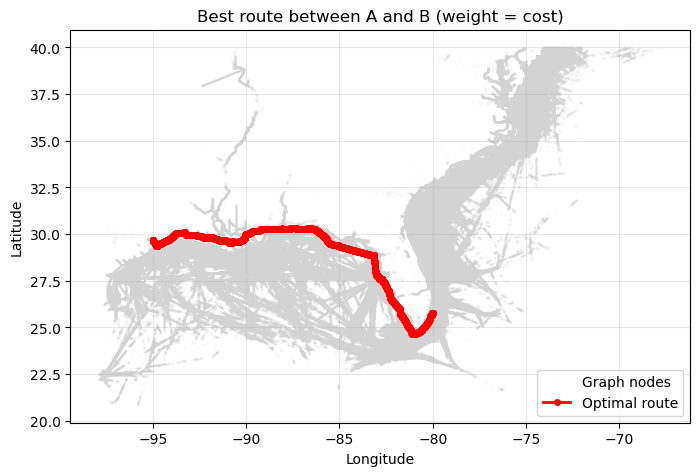

In [9]:

lat_A, lon_A = 29.7, -95.0   # Houston / Galveston
lat_B, lon_B = 25.8, -80.0   # Miami

# Pour visualiser tous les nœuds (à ne pas garder pour toujours, mais pour vérifier)
plot_route(lat_A, lon_A, lat_B, lon_B, weight_attr="cost", sample_bg=len(node_lats))

Start node: 441542, End node: 457129


Path length (nodes): 1738
Total approx distance (km): 642.5
Total cost: 391.252


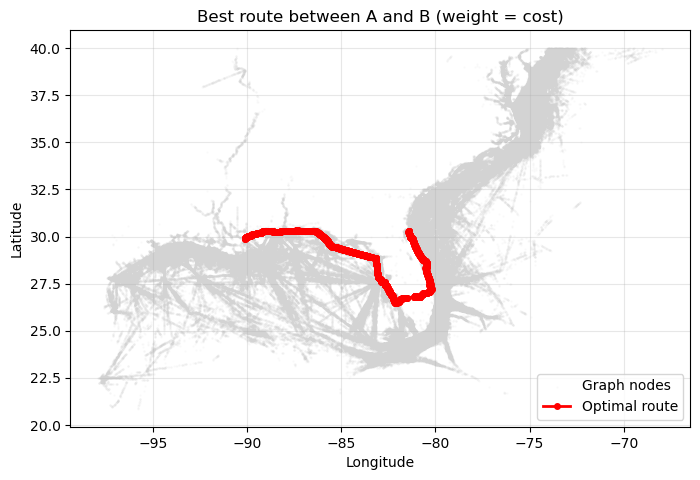

In [10]:

lat_A, lon_A = 29.9, -90.1   # New Orleans
lat_B, lon_B = 30.3, -81.4   # Jacksonville

plot_route(lat_A, lon_A, lat_B, lon_B, weight_attr="cost")

Start node: 349234, End node: 422731
Path length (nodes): 381
Total approx distance (km): 105.6
Total cost: 51.019


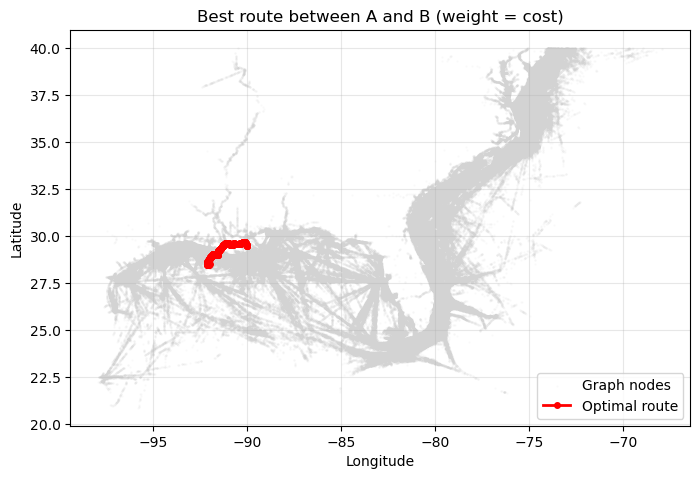

In [11]:
#deux point proches
lat_A, lon_A = 28.5, -92.0
lat_B, lon_B = 29.5, -90.0

plot_route(lat_A, lon_A, lat_B, lon_B, weight_attr="cost")

## Ports : meilleure route entre deux ports

Liste de ports dans la zone focus (CSV `data/ports_focus_zone.csv`)

In [12]:
import pandas as pd
import numpy as np
import networkx as nx

# Load the port list (expected at data/ports_focus_zone.csv)
ports_path = base_dir / "data" / "ports_focus_zone.csv"
if not ports_path.exists():
    ports_path = base_dir / "ports_focus_zone.csv"  # fallback if data/ is not present
ports_df = pd.read_csv(ports_path)
ports_df = ports_df.set_index("port_id")
print("Available ports:", list(ports_df.index))
display(ports_df)


def nearest_k_nodes(lat, lon, k=20):
    """Return k nearest graph nodes to a (lat, lon) point."""
    d2 = (node_lats - lat) ** 2 + (node_lons - lon) ** 2
    k = min(k, len(node_ids))
    idx = np.argpartition(d2, k - 1)[:k]
    idx = idx[np.argsort(d2[idx])]
    return [int(node_ids[i]) for i in idx], d2[idx]


def best_path_between_points_robust(lat_start, lon_start, lat_end, lon_end, weight_attr="cost", k=20):
    """
    Robust routing between two points:
    - sample top-k nearest start/end nodes
    - keep only directed-feasible pairs
    - pick pair with smallest snap error, then smallest path cost
    """
    start_cands, d2_start = nearest_k_nodes(lat_start, lon_start, k=k)
    end_cands, d2_end = nearest_k_nodes(lat_end, lon_end, k=k)

    d_start = {n: float(d2_start[i]) for i, n in enumerate(start_cands)}
    d_end = {n: float(d2_end[i]) for i, n in enumerate(end_cands)}

    best = None  # ((snap_penalty, path_cost), s, t, path_nodes)
    for s in start_cands:
        for t in end_cands:
            if not nx.has_path(G, s, t):
                continue
            snap_penalty = d_start[s] + d_end[t]
            try:
                path_nodes = nx.shortest_path(G, source=s, target=t, weight=weight_attr)
            except nx.NetworkXNoPath:
                continue

            path_cost = 0.0
            for a, b in zip(path_nodes[:-1], path_nodes[1:]):
                path_cost += float(G[a][b].get(weight_attr, 0.0))

            key = (snap_penalty, path_cost)
            if (best is None) or (key < best[0]):
                best = (key, s, t, path_nodes)

    if best is None:
        print(f"No directed path found among top-{k} nearest candidates.")
        return None, None, None

    _, s, t, path_nodes = best
    print(f"Start node: {s}, End node: {t} (robust top-{k})")

    path_lats = [G.nodes[n]["lat"] for n in path_nodes]
    path_lons = [G.nodes[n]["lon"] for n in path_nodes]

    total_dist = 0.0
    total_cost = 0.0
    for a, b in zip(path_nodes[:-1], path_nodes[1:]):
        d = G[a][b]
        total_dist += float(d.get("avg_dist_km", 0.0))
        total_cost += float(d.get(weight_attr, 0.0))

    print(f"Path length (nodes): {len(path_nodes)}")
    print(f"Total approx distance (km): {total_dist:.1f}")
    print(f"Total cost: {total_cost:.3f}")
    return path_nodes, path_lats, path_lons


def best_path_between_ports(port_start_id, port_end_id, weight_attr="cost", robust=True, k=20):
    """Best route between two ports (by id)."""
    row_start = ports_df.loc[port_start_id]
    row_end = ports_df.loc[port_end_id]
    if robust:
        return best_path_between_points_robust(
            row_start["lat"], row_start["lon"],
            row_end["lat"], row_end["lon"],
            weight_attr=weight_attr, k=k
        )
    return best_path_between_points(
        row_start["lat"], row_start["lon"],
        row_end["lat"], row_end["lon"],
        weight_attr=weight_attr
    )


def plot_route_between_ports(port_start_id, port_end_id, weight_attr="cost", sample_bg=200_000, robust=True, k=20):
    """Visualize the best route between two ports."""
    row_start = ports_df.loc[port_start_id]
    row_end = ports_df.loc[port_end_id]
    if robust:
        path_nodes, path_lats, path_lons = best_path_between_points_robust(
            row_start["lat"], row_start["lon"],
            row_end["lat"], row_end["lon"],
            weight_attr=weight_attr, k=k
        )
        if path_nodes is None:
            return

        if len(node_lats) > sample_bg:
            idx = np.random.choice(len(node_lats), size=sample_bg, replace=False)
            bg_lats = node_lats[idx]
            bg_lons = node_lons[idx]
        else:
            bg_lats = node_lats
            bg_lons = node_lons

        plt.figure(figsize=(8, 8))
        plt.scatter(bg_lons, bg_lats, s=1, alpha=0.05, color="lightgray", label="Graph nodes")
        plt.plot(path_lons, path_lats, "-o", color="red", linewidth=2, markersize=4, label="Optimal route")
        plt.xlabel("Longitude"); plt.ylabel("Latitude")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.title(f"Best route between ports (weight = {weight_attr}, robust k={k})")
        plt.show()
        return

    plot_route(
        row_start["lat"], row_start["lon"],
        row_end["lat"], row_end["lon"],
        weight_attr=weight_attr, sample_bg=sample_bg
    )


# Example: Houston -> New York

Available ports: ['houston', 'galveston', 'new_orleans', 'tampa', 'miami', 'jacksonville', 'savannah', 'charleston', 'norfolk', 'baltimore', 'philadelphia', 'new_york', 'havana', 'veracruz', 'mobile', 'panama_city', 'port_everglades', 'freeport', 'san_juan']


,name,lat,lon
port_id,,,
houston,Houston,29.76,-95.37
galveston,Galveston,29.30,-94.80
new_orleans,New Orleans,29.95,-90.07
tampa,Tampa,27.95,-82.46
miami,Miami,25.77,-80.19
jacksonville,Jacksonville,30.33,-81.66
savannah,Savannah,32.08,-81.09
charleston,Charleston,32.79,-79.93
norfolk,Norfolk,36.85,-76.29


=== Gulf_to_EastCoast ===
Start node: 284934, End node: 509660


Path length (nodes): 3137
Total approx distance (km): 1192.6
Total cost: 711.626
Total distance ~ 1192.6 km, total cost ~ 711.6
Start node: 284934, End node: 509660
Path length (nodes): 3137
Total approx distance (km): 1192.6
Total cost: 711.626


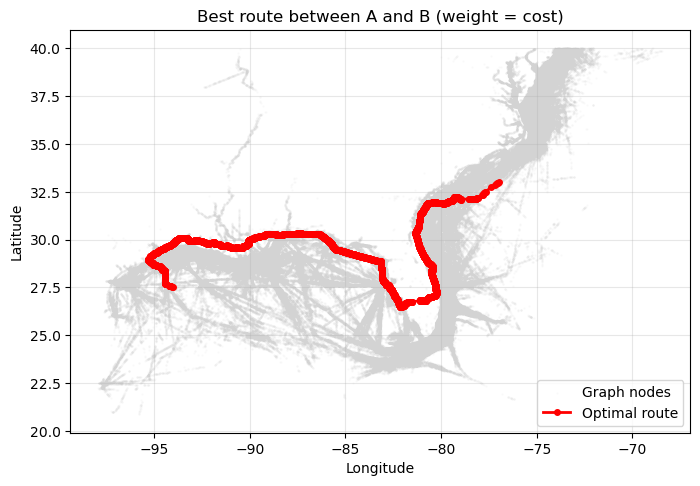

=== Miami_to_NewYork ===
Start node: 219820, End node: 623527
Path length (nodes): 2325
Total approx distance (km): 586.0
Total cost: 358.237
Total distance ~ 586.0 km, total cost ~ 358.2
Start node: 219820, End node: 623527
Path length (nodes): 2325
Total approx distance (km): 586.0
Total cost: 358.237


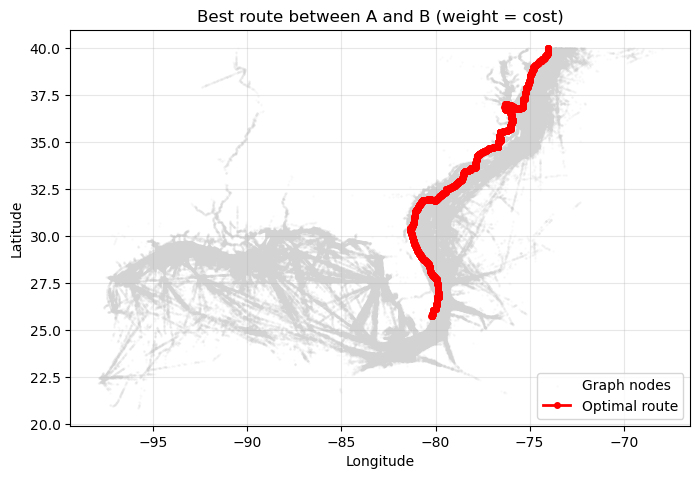

=== Houston_to_PuertoRico ===
Start node: 434055, End node: 128358
No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.
=== Gulf_to_FloridaStraits ===
Start node: 175089, End node: 174022
No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.


In [13]:
scenarios = {
    "Gulf_to_EastCoast": dict(
        lat_A=27.5, lon_A=-94.0,   # large Golfe du Mexique
        lat_B=33.0, lon_B=-77.0    # large Caroline du Nord
    ),
    "Miami_to_NewYork": dict(
        lat_A=25.8, lon_A=-80.2,   # Miami approx
        lat_B=40.7, lon_B=-74.0    # New York approx
    ),
    "Houston_to_PuertoRico": dict(
        lat_A=29.7, lon_A=-95.0,   # Houston/Galveston approx
        lat_B=18.4, lon_B=-66.1    # San Juan, PR approx
    ),
    "Gulf_to_FloridaStraits": dict(
        lat_A=24.5, lon_A=-90.0,   # centre Golfe
        lat_B=24.5, lon_B=-81.5    # Détroit de Floride / Key West approx
    ),
}

for name, cfg in scenarios.items():
    print(f"=== {name} ===")
    lat_A, lon_A = cfg["lat_A"], cfg["lon_A"]
    lat_B, lon_B = cfg["lat_B"], cfg["lon_B"]

    # best_path_between_points ne renvoie que les nœuds + coords
    path_nodes, path_lats, path_lons = best_path_between_points(
        lat_A, lon_A, lat_B, lon_B,
        weight_attr="cost",
    )
    if path_nodes is None:
        continue

    # Recalcule distance totale et coût total le long du chemin
    total_dist_km = 0.0
    total_cost = 0.0
    for a, b in zip(path_nodes[:-1], path_nodes[1:]):
        d = G[a][b]
        total_dist_km += float(d.get("avg_dist_km", 0.0))
        total_cost += float(d.get("cost", 0.0))

    print(f"Total distance ~ {total_dist_km:.1f} km, total cost ~ {total_cost:.1f}")

    # appel sans 'title' (signature actuelle de plot_route)
    plot_route(
        lat_A, lon_A, lat_B, lon_B,
        weight_attr="cost",
    )

## Données Copernicus (courants de surface) – features météo pour le graphe



In [14]:
# Chargement des courants Copernicus (daily) et ajout aux nœuds de G
import numpy as np
import xarray as xr
from pathlib import Path

base_dir = Path(".").resolve()

# Courants
meteo_path_jan = base_dir / "currents_jan2024.nc"
print("Météo (courants) – chargement depuis:", meteo_path_jan)

if not meteo_path_jan.exists():
    print("ATTENTION: le fichier de courants Copernicus n'existe pas encore à cet emplacement.")
else:
    ds_cur = xr.open_dataset(meteo_path_jan)
    print(ds_cur)

    # Les noms de dimensions/coordonnées peuvent être 'latitude'/'longitude' ou 'lat'/'lon'
    # On essaie d'abord 'latitude'/'longitude', puis on tombe en secours sur 'lat'/'lon'.
    if "latitude" in ds_cur.dims and "longitude" in ds_cur.dims:
        lat_name, lon_name = "latitude", "longitude"
    elif "lat" in ds_cur.dims and "lon" in ds_cur.dims:
        lat_name, lon_name = "lat", "lon"
    else:
        raise ValueError("Impossible de trouver les dimensions latitude/longitude dans le NetCDF Copernicus.")

    # Moyenne temporelle sur la période téléchargée (daily → moyenne sur 'time')
    uo_mean = ds_cur["uo"].mean(dim="time")  # [lat, lon]
    vo_mean = ds_cur["vo"].mean(dim="time")

    def add_currents_to_nodes(G, u_da, v_da, lat_name, lon_name):
        """Ajoute u_cur / v_cur aux attributs des nœuds de G via interpolation plus proche voisin."""
        for n, data in G.nodes(data=True):
            lat = float(data["lat"])
            lon = float(data["lon"])
            # sélection du point de grille le plus proche
            u_val = u_da.sel({lat_name: lat, lon_name: lon}, method="nearest").values.squeeze()
            v_val = v_da.sel({lat_name: lat, lon_name: lon}, method="nearest").values.squeeze()

            # Si on tombe sur une case "terre" (NaN), on met 0 par défaut
            if not np.isfinite(u_val):
                u_val = 0.0
            if not np.isfinite(v_val):
                v_val = 0.0

            data["u_cur"] = float(u_val)
            data["v_cur"] = float(v_val)

    add_currents_to_nodes(G, uo_mean, vo_mean, lat_name, lon_name)

    # Vérification rapide sur quelques nœuds
    example_nodes = list(G.nodes())[:3]
    for n in example_nodes:
        d = G.nodes[n]
        print(f"Node {n}: lat={d['lat']:.3f}, lon={d['lon']:.3f}, u_cur={d['u_cur']:.4f}, v_cur={d['v_cur']:.4f}")

Météo (courants) – chargement depuis: /users/eleves-b/2023/marc.saade/bachelor-thesis/thesis/currents_jan2024.nc
<xarray.Dataset>
Dimensions:    (time: 14, depth: 1, latitude: 301, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 2024-01-01 2024-01-02 ... 2024-01-14
  * depth      (depth) float32 0.494
  * latitude   (latitude) float32 15.0 15.08 15.17 15.25 ... 39.83 39.92 40.0
  * longitude  (longitude) float32 -100.0 -99.92 -99.83 ... -60.25 -60.17 -60.08
Data variables:
    uo         (time, depth, latitude, longitude) float32 ...
    vo         (time, depth, latitude, longitude) float32 ...
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institution:       Mercator Ocean International
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MOI GLO12
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           ht

Node 125093: lat=20.853, lon=-95.780, u_cur=-0.4410, v_cur=0.4513
Node 125152: lat=20.859, lon=-95.779, u_cur=-0.4410, v_cur=0.4513
Node 125217: lat=20.870, lon=-95.779, u_cur=-0.4410, v_cur=0.4513


In [15]:
#Température de surface Copernicus comme feature supplémentaire

meteo_temp_path_jan = base_dir / "temperature_jan2024.nc"
print("Météo (température) – chargement depuis:", meteo_temp_path_jan)

if not meteo_temp_path_jan.exists():
    print("ATTENTION: fichier température manquant, on ne crée pas la feature 'sst'.")
else:
    ds_temp = xr.open_dataset(meteo_temp_path_jan)
    # adapter le nom de variable si nécessaire (thetao, sst, etc.)
    var_name = "thetao" if "thetao" in ds_temp.data_vars else "sst"
    temp_mean = ds_temp[var_name].mean(dim="time").isel(depth=0)  # surface

    def add_temp_to_nodes(G, t_da, lat_name, lon_name):
        for n, data in G.nodes(data=True):
            lat = float(data["lat"])
            lon = float(data["lon"])
            t_val = t_da.sel({lat_name: lat, lon_name: lon}, method="nearest").values.squeeze()
            if not np.isfinite(t_val):
                t_val = 0.0
            data["sst"] = float(t_val)

    add_temp_to_nodes(G, temp_mean, lat_name, lon_name)

    # Vérif
    for n in list(G.nodes())[:3]:
        d = G.nodes[n]
        print(f"Node {n}: sst={d['sst']:.2f}")

Météo (température) – chargement depuis: /users/eleves-b/2023/marc.saade/bachelor-thesis/thesis/temperature_jan2024.nc
Node 125093: sst=24.18
Node 125152: sst=24.18
Node 125217: sst=24.18


## Classification d'arêtes (GCN) : arête sur route optimale = 1, hors route = 0


In [16]:
# Classification d'arêtes : création dataset supervisé (labels) à partir de routes port→port
# NOTE : on (re)construit ici les features PyG (indépendant de l'ancienne partie supprimée).

import random
import pandas as pd
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

# 1) Mapping nœud NetworkX -> index PyG (l'ordre de G.nodes() est utilisé par from_networkx)
node_list = list(G.nodes())
orig_to_idx = {n: i for i, n in enumerate(node_list)}

# 2) Construire Data PyG + features nœuds (lat, lon, log(deg_in), log(deg_out))
node_attrs = ["lat", "lon", "u_cur", "v_cur", "sst"]
data_base = from_networkx(G, group_node_attrs=node_attrs)
edge_index = data_base.edge_index
num_nodes = data_base.num_nodes

# Degré entrant / sortant (calculé sur edge_index)
deg_out = torch.zeros(num_nodes, dtype=torch.float32)
deg_in = torch.zeros(num_nodes, dtype=torch.float32)
ones = torch.ones(edge_index.size(1), dtype=torch.float32)
deg_out.index_add_(0, edge_index[0], ones)
deg_in.index_add_(0, edge_index[1], ones)

data_base.x = torch.cat(
    [data_base.x, torch.log1p(deg_in).unsqueeze(1), torch.log1p(deg_out).unsqueeze(1)],
    dim=1,
)

# 3) Générer labels positifs : arêtes sur les routes Dijkstra entre ports
ports_df = pd.read_csv(base_dir / "data" / "ports_focus_zone.csv")

PORT_PAIRS = [
    ("houston", "miami"),
    ("new_orleans", "new_york"),
    ("tampa", "miami"),
    ("miami", "new_york"),
    ("houston", "new_orleans"),
    ("galveston", "tampa"),
]

positive_edges = set()
for pid_a, pid_b in PORT_PAIRS:
    row_a = ports_df[ports_df["port_id"] == pid_a].iloc[0]
    row_b = ports_df[ports_df["port_id"] == pid_b].iloc[0]

    path_nodes, _, _ = best_path_between_points_robust(
        row_a["lat"], row_a["lon"],
        row_b["lat"], row_b["lon"],
        weight_attr="cost",
        k = 3
    )
    if path_nodes is None:
        continue

    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        if G.has_edge(u, v):
            positive_edges.add((u, v))

if len(positive_edges) == 0:
    raise ValueError("Aucune arête positive trouvée (aucune route Dijkstra trouvée). Choisir d'autres paires de ports.")

# 4) Négatifs : échantillonner des arêtes hors routes
all_edges = list(G.edges())
negative_candidates = [(u, v) for (u, v) in all_edges if (u, v) not in positive_edges]
random.seed(42)
n_neg = min(len(negative_candidates), len(positive_edges) * 2)
negative_edges = set(random.sample(negative_candidates, n_neg))

# 5) Construire edge_label_index / edge_label (indices PyG)
def edge_to_idx(u, v):
    i = orig_to_idx.get(u)
    j = orig_to_idx.get(v)
    if i is None or j is None:
        return None
    return (i, j)

pos_list = [edge_to_idx(u, v) for (u, v) in positive_edges]
pos_list = [x for x in pos_list if x is not None]
neg_list = [edge_to_idx(u, v) for (u, v) in negative_edges]
neg_list = [x for x in neg_list if x is not None]

src = [p[0] for p in pos_list] + [n[0] for n in neg_list]
dst = [p[1] for p in pos_list] + [n[1] for n in neg_list]
labels = [1.0] * len(pos_list) + [0.0] * len(neg_list)

edge_label_index = torch.tensor([src, dst], dtype=torch.long)
edge_label = torch.tensor(labels, dtype=torch.float32)

# Shuffle + split
perm = torch.randperm(edge_label_index.size(1))
edge_label_index = edge_label_index[:, perm]
edge_label = edge_label[perm]

n_total = edge_label_index.size(1)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_clf = Data(x=data_base.x, edge_index=data_base.edge_index, edge_label_index=edge_label_index[:, :n_train], edge_label=edge_label[:n_train])
val_clf = Data(x=data_base.x, edge_index=data_base.edge_index, edge_label_index=edge_label_index[:, n_train:n_train + n_val], edge_label=edge_label[n_train:n_train + n_val])
test_clf = Data(x=data_base.x, edge_index=data_base.edge_index, edge_label_index=edge_label_index[:, n_train + n_val:], edge_label=edge_label[n_train + n_val:])

print(f"Classification: {len(positive_edges)} positives, {len(negative_edges)} negatives")
print(f"Train {train_clf.edge_label_index.size(1)}, Val {val_clf.edge_label_index.size(1)}, Test {test_clf.edge_label_index.size(1)}")

Start node: 436682, End node: 218762 (robust top-3)
Path length (nodes): 2257
Total approx distance (km): 668.1
Total cost: 351.686
Start node: 443987, End node: 622587 (robust top-3)
Path length (nodes): 3474
Total approx distance (km): 1060.3
Total cost: 653.007
Start node: 316454, End node: 218762 (robust top-3)
Path length (nodes): 598
Total approx distance (km): 260.2
Total cost: 154.014
Start node: 218762, End node: 622587 (robust top-3)
Path length (nodes): 2327
Total approx distance (km): 617.1
Total cost: 381.333
Start node: 436682, End node: 443987 (robust top-3)
Path length (nodes): 728
Total approx distance (km): 150.4
Total cost: 40.385
Start node: 412591, End node: 316454 (robust top-3)
Path length (nodes): 1675
Total approx distance (km): 425.8
Total cost: 204.562
Classification: 5103 positives, 10206 negatives
Train 10716, Val 2296, Test 2297


## Node classification (GCN) on branching + port nodes


In [17]:
# Build node-level dataset: labels on ports + branching nodes

# 1) Recompute degrees on the same edge_index used for GCN
edge_index = data_base.edge_index
num_nodes = data_base.num_nodes

# 2) Interesting nodes = branching nodes (degree > 1) + ports
ports_df = pd.read_csv(base_dir / "data" / "ports_focus_zone.csv")

port_nodes = set()
for _, row in ports_df.iterrows():
    port_nodes.add(nearest_node(row["lat"], row["lon"]))

branching_set = set(branching_nodes)
interesting_nodes = branching_set | port_nodes

interesting_mask = torch.zeros(num_nodes, dtype=torch.bool)
for n in interesting_nodes:
    idx = orig_to_idx.get(n)
    if idx is not None:
        interesting_mask[idx] = True

print(f"Total nodes: {num_nodes}, interesting nodes (ports + branches): {interesting_mask.sum().item()}")

# 3) Node labels: 1 if on any Dijkstra route for the PORT_PAIRS, else 0
node_labels = torch.zeros(num_nodes, dtype=torch.float32)

for pid_a, pid_b in PORT_PAIRS:
    row_a = ports_df[ports_df["port_id"] == pid_a].iloc[0]
    row_b = ports_df[ports_df["port_id"] == pid_b].iloc[0]

    path_nodes, _, _ = best_path_between_points_robust(
        row_a["lat"], row_a["lon"],
        row_b["lat"], row_b["lon"],
        weight_attr="cost",
        k = 3
    )
    if path_nodes is None:
        continue

    for n in path_nodes:
        idx = orig_to_idx.get(n)
        if idx is not None:
            node_labels[idx] = 1.0

print("Positive node labels:", int(node_labels.sum().item()))

# 4) Train/val/test split over interesting nodes
indices = torch.nonzero(interesting_mask, as_tuple=False).view(-1)
perm_nodes = indices[torch.randperm(indices.numel())]

n_total = perm_nodes.numel()
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_idx = perm_nodes[:n_train]
val_idx = perm_nodes[n_train:n_train + n_val]
test_idx = perm_nodes[n_train + n_val:]

print(f"Train nodes: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Total nodes: 485977, interesting nodes (ports + branches): 242479
Start node: 436682, End node: 218762 (robust top-3)
Path length (nodes): 2257
Total approx distance (km): 668.1
Total cost: 351.686
Start node: 443987, End node: 622587 (robust top-3)
Path length (nodes): 3474
Total approx distance (km): 1060.3
Total cost: 653.007
Start node: 316454, End node: 218762 (robust top-3)
Path length (nodes): 598
Total approx distance (km): 260.2
Total cost: 154.014
Start node: 218762, End node: 622587 (robust top-3)
Path length (nodes): 2327
Total approx distance (km): 617.1
Total cost: 381.333
Start node: 436682, End node: 443987 (robust top-3)
Path length (nodes): 728
Total approx distance (km): 150.4
Total cost: 40.385
Start node: 412591, End node: 316454 (robust top-3)
Path length (nodes): 1675
Total approx distance (km): 425.8
Total cost: 204.562
Positive node labels: 5057
Train nodes: 169735, Val: 36371, Test: 36373


In [18]:
# Node-level GCN model and training loop

class NodeGCN(nn.Module):
    def __init__(self, in_channels, hidden=128):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.dropout = nn.Dropout(0.2)
        self.lin = nn.Linear(hidden, 1)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.dropout(h)
        h = self.conv2(h, edge_index).relu()
        out = self.lin(h).squeeze(-1)
        return out

# ---- device + perf flags ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.cuda.empty_cache()

# Clean any remaining NaNs in features
x_nodes = data_base.x.clone()
mask_nan = torch.isnan(x_nodes)
if mask_nan.any():
    x_nodes[mask_nan] = 0.0

x_nodes = x_nodes.to(device)
edge_index_nodes = edge_index.to(device)
y_nodes = node_labels.to(device)

model_node = NodeGCN(in_channels=x_nodes.size(1)).to(device)
optimizer_node = torch.optim.Adam(model_node.parameters(), lr=1e-3)
criterion_node = nn.BCEWithLogitsLoss()

train_idx_dev = train_idx.to(device)
val_idx_dev = val_idx.to(device)
test_idx_dev = test_idx.to(device)

use_amp = (device.type == "cuda")
amp_dtype = torch.bfloat16  # better stability than float16 on recent GPUs

def train_node_epoch():
    model_node.train()
    optimizer_node.zero_grad(set_to_none=True)

    if use_amp:
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            logits = model_node(x_nodes, edge_index_nodes)
            loss = criterion_node(logits[train_idx_dev], y_nodes[train_idx_dev])
    else:
        logits = model_node(x_nodes, edge_index_nodes)
        loss = criterion_node(logits[train_idx_dev], y_nodes[train_idx_dev])

    loss.backward()
    optimizer_node.step()
    return float(loss.item())

def eval_node_auc(idx_dev):
    model_node.eval()
    with torch.no_grad():
        if use_amp:
            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                logits = model_node(x_nodes, edge_index_nodes)[idx_dev]
        else:
            logits = model_node(x_nodes, edge_index_nodes)[idx_dev]

        probs = torch.sigmoid(logits).float().cpu().numpy()
        labels = y_nodes[idx_dev].float().cpu().numpy()

    if labels.mean() == 0 or labels.mean() == 1:
        return float("nan")
    return float(roc_auc_score(labels, probs))

EPOCHS_NODE = 200
for epoch in range(1, EPOCHS_NODE + 1):
    try:
        loss = train_node_epoch()
    except torch.cuda.OutOfMemoryError:
        print("CUDA OOM at epoch", epoch, "-> clearing cache and falling back to CPU")
        torch.cuda.empty_cache()

        # fallback without changing model logic
        model_node_cpu = model_node.to("cpu")
        x_nodes_cpu = x_nodes.to("cpu")
        edge_index_cpu = edge_index_nodes.to("cpu")
        y_nodes_cpu = y_nodes.to("cpu")
        train_idx_cpu = train_idx_dev.to("cpu")
        val_idx_cpu = val_idx_dev.to("cpu")
        test_idx_cpu = test_idx_dev.to("cpu")

        # replace refs for remainder
        model_node = model_node_cpu
        x_nodes = x_nodes_cpu
        edge_index_nodes = edge_index_cpu
        y_nodes = y_nodes_cpu
        train_idx_dev = train_idx_cpu
        val_idx_dev = val_idx_cpu
        test_idx_dev = test_idx_cpu
        use_amp = False
        device = torch.device("cpu")

        loss = train_node_epoch()

    val_auc = eval_node_auc(val_idx_dev)
    if epoch == 1 or epoch % 5 == 0:
        print(f"[Node] Epoch {epoch:02d} loss={loss:.4f} val_AUC={val_auc:.4f}")

print(f"[Node] Test AUC: {eval_node_auc(test_idx_dev):.4f}")

Device: cuda
CUDA OOM at epoch 1 -> clearing cache and falling back to CPU
[Node] Epoch 01 loss=1.2891 val_AUC=0.3723
[Node] Epoch 05 loss=0.1378 val_AUC=0.4858
[Node] Epoch 10 loss=0.2100 val_AUC=0.5033
[Node] Epoch 15 loss=0.2272 val_AUC=0.5121
[Node] Epoch 20 loss=0.2183 val_AUC=0.5141
[Node] Epoch 25 loss=0.1959 val_AUC=0.5126
[Node] Epoch 30 loss=0.1678 val_AUC=0.5170
[Node] Epoch 35 loss=0.1380 val_AUC=0.5150
[Node] Epoch 40 loss=0.1117 val_AUC=0.5140
[Node] Epoch 45 loss=0.0986 val_AUC=0.5131
[Node] Epoch 50 loss=0.1041 val_AUC=0.5148
[Node] Epoch 55 loss=0.1015 val_AUC=0.5258
[Node] Epoch 60 loss=0.0967 val_AUC=0.5695
[Node] Epoch 65 loss=0.0972 val_AUC=0.5758
[Node] Epoch 70 loss=0.0952 val_AUC=0.5574
[Node] Epoch 75 loss=0.0945 val_AUC=0.5769
[Node] Epoch 80 loss=0.0935 val_AUC=0.6129
[Node] Epoch 85 loss=0.0920 val_AUC=0.6518
[Node] Epoch 90 loss=0.0905 val_AUC=0.6839
[Node] Epoch 95 loss=0.0898 val_AUC=0.7015
[Node] Epoch 100 loss=0.0890 val_AUC=0.7124
[Node] Epoch 105 loss

In [19]:
# Edge-GCN training for route-edge classification (on-route=1, off-route=0)

import torch
from torch import nn
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score

class EdgeGCNClassifier(nn.Module):
    def __init__(self, in_channels, hidden=128):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.dropout = nn.Dropout(0.2)
        self.mlp = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def encode(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.dropout(h)
        h = self.conv2(h, edge_index)
        return h

    def decode(self, z, edge_label_index):
        z_src = z[edge_label_index[0]]
        z_dst = z[edge_label_index[1]]
        return self.mlp(torch.cat([z_src, z_dst], dim=-1)).squeeze(-1)

# ---- device + perf flags ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.cuda.empty_cache()

model_clf = EdgeGCNClassifier(in_channels=train_clf.x.size(-1)).to(device)
optimizer = torch.optim.Adam(model_clf.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

use_amp = (device.type == "cuda")
amp_dtype = torch.bfloat16  # good compromise for Ada cards

def train_step(split):
    model_clf.train()
    optimizer.zero_grad(set_to_none=True)

    x = split.x.to(device, non_blocking=True)
    edge_index = split.edge_index.to(device, non_blocking=True)
    edge_label_index = split.edge_label_index.to(device, non_blocking=True)
    y = split.edge_label.to(device, non_blocking=True)

    if use_amp:
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            z = model_clf.encode(x, edge_index)
            logits = model_clf.decode(z, edge_label_index)
            loss = criterion(logits, y)
    else:
        z = model_clf.encode(x, edge_index)
        logits = model_clf.decode(z, edge_label_index)
        loss = criterion(logits, y)

    loss.backward()
    optimizer.step()
    return float(loss.item())

def eval_auc(split):
    model_clf.eval()
    x = split.x.to(device, non_blocking=True)
    edge_index = split.edge_index.to(device, non_blocking=True)
    edge_label_index = split.edge_label_index.to(device, non_blocking=True)
    y = split.edge_label.cpu().numpy()

    with torch.no_grad():
        if use_amp:
            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                z = model_clf.encode(x, edge_index)
                logits = model_clf.decode(z, edge_label_index)
        else:
            z = model_clf.encode(x, edge_index)
            logits = model_clf.decode(z, edge_label_index)

        probs = torch.sigmoid(logits).float().cpu().numpy()

    return float(roc_auc_score(y, probs))

EPOCHS = 200
for epoch in range(1, EPOCHS + 1):
    try:
        loss = train_step(train_clf)
    except torch.cuda.OutOfMemoryError:
        print(f"CUDA OOM at epoch {epoch}, clearing cache and switching to CPU fallback.")
        torch.cuda.empty_cache()

        # Move model to CPU and continue training
        model_clf = model_clf.to("cpu")
        device = torch.device("cpu")
        use_amp = False

        loss = train_step(train_clf)

    val_auc = eval_auc(val_clf)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} loss={loss:.4f} val_AUC={val_auc:.4f}")

print(f"Test AUC (route edge classification): {eval_auc(test_clf):.4f}")

Device: cuda
CUDA OOM at epoch 1, clearing cache and switching to CPU fallback.
Epoch 01 loss=1.8847 val_AUC=0.3728
Epoch 05 loss=0.7834 val_AUC=0.5423
Epoch 10 loss=0.6291 val_AUC=0.6875
Epoch 15 loss=0.6577 val_AUC=0.7179
Epoch 20 loss=0.6352 val_AUC=0.7225
Epoch 25 loss=0.5995 val_AUC=0.7272
Epoch 30 loss=0.5779 val_AUC=0.7251
Epoch 35 loss=0.5778 val_AUC=0.7264
Epoch 40 loss=0.5793 val_AUC=0.7273
Epoch 45 loss=0.5777 val_AUC=0.7273
Epoch 50 loss=0.5714 val_AUC=0.7287
Epoch 55 loss=0.5705 val_AUC=0.7290
Epoch 60 loss=0.5723 val_AUC=0.7300
Epoch 65 loss=0.5697 val_AUC=0.7300
Epoch 70 loss=0.5691 val_AUC=0.7304
Epoch 75 loss=0.5673 val_AUC=0.7323
Epoch 80 loss=0.5653 val_AUC=0.7323
Epoch 85 loss=0.5636 val_AUC=0.7338
Epoch 90 loss=0.5622 val_AUC=0.7349
Epoch 95 loss=0.5617 val_AUC=0.7370
Epoch 100 loss=0.5588 val_AUC=0.7396
Epoch 105 loss=0.5562 val_AUC=0.7434
Epoch 110 loss=0.5550 val_AUC=0.7464
Epoch 115 loss=0.5522 val_AUC=0.7501
Epoch 120 loss=0.5470 val_AUC=0.7541
Epoch 125 loss=

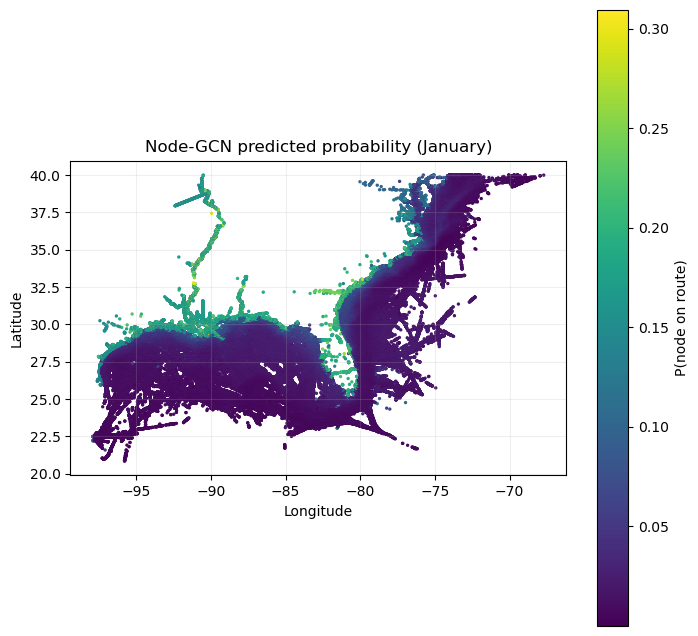

In [20]:
# 1) Récupérer les probabilités prédictes pour tous les nœuds
model_node.eval()
with torch.no_grad():
    logits_all = model_node(x_nodes, edge_index_nodes)
    probs_all = torch.sigmoid(logits_all).cpu().numpy()

# 2) Récupérer lat/lon associés à chaque nœud
# Attention: lat/lon sont les 2 premières colonnes de data_base.x
lats = data_base.x[:, 0].cpu().numpy()
lons = data_base.x[:, 1].cpu().numpy()

# 3) Plot carte complète (peut être dense)
plt.figure(figsize=(8, 8))
plt.scatter(lons, lats, c=probs_all, s=2, cmap="viridis")
plt.colorbar(label="P(node on route)")
plt.title("Node-GCN predicted probability (January)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.2)
plt.show()

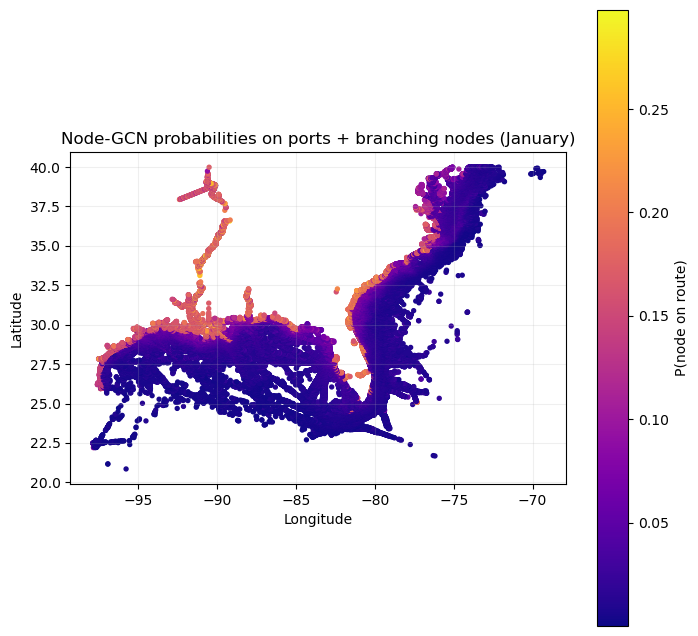

In [21]:
interesting_probs = probs_all[interesting_mask.numpy()]
interesting_lats = lats[interesting_mask.numpy()]
interesting_lons = lons[interesting_mask.numpy()]

plt.figure(figsize=(8, 8))
plt.scatter(interesting_lons, interesting_lats, c=interesting_probs, s=8, cmap="plasma")
plt.colorbar(label="P(node on route)")
plt.title("Node-GCN probabilities on ports + branching nodes (January)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.2)
plt.show()

In [22]:
# embeddings de tous les nœuds (GPU)
model_clf.eval()
with torch.no_grad():
    x_dev = data_base.x.to(device)
    edge_index_dev = data_base.edge_index.to(device)
    z_all = model_clf.encode(x_dev, edge_index_dev)  # z_all sur device

# probas pour toutes les arêtes du graphe (GPU aussi)
all_edges = list(G.edges())
src_idx = [orig_to_idx[u] for (u, v) in all_edges]
dst_idx = [orig_to_idx[v] for (u, v) in all_edges]
edge_index_all = torch.tensor([src_idx, dst_idx], dtype=torch.long, device=device)

with torch.no_grad():
    logits_edges = model_clf.decode(z_all, edge_index_all)  # tout sur device
    probs_edges = torch.sigmoid(logits_edges).cpu().numpy()  # on repasse en CPU seulement ici

Threshold used: 0.6956
Number of selected edges: 10175


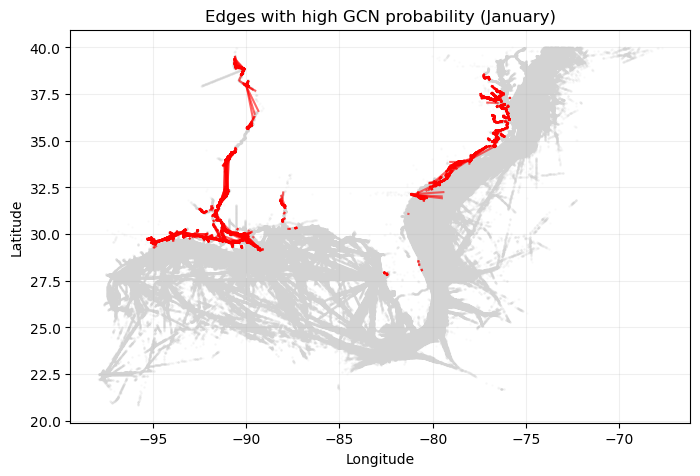

In [31]:
# Keep only top-probability edges using a quantile threshold (more robust than fixed 0.8)
# probs_edges must correspond to all_edges (same order/length)

thr = np.quantile(probs_edges, 0.99)  # top 1%; use 0.98 for top 2%
mask_high = probs_edges >= thr
high_edges = [e for e, m in zip(all_edges, mask_high) if m]

print(f"Threshold used: {thr:.4f}")
print(f"Number of selected edges: {len(high_edges)}")

# Mini-plot
plt.figure(figsize=(8, 8))

# Light background (all graph nodes)
plt.scatter(lons, lats, s=1, alpha=0.05, color="lightgray")

# Highlight selected edges
for (u, v) in high_edges:
    lat_u, lon_u = G.nodes[u]["lat"], G.nodes[u]["lon"]
    lat_v, lon_v = G.nodes[v]["lat"], G.nodes[v]["lon"]
    plt.plot([lon_u, lon_v], [lat_u, lat_v], color="red", alpha=0.6)

plt.title("Edges with high GCN probability (January)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.2)
plt.show()

In [25]:
print("n_probs:", len(probs_edges))
print("min/max:", float(probs_edges.min()), float(probs_edges.max()))
print("q90/q95/q99:", *np.quantile(probs_edges, [0.90, 0.95, 0.99]))
print(">0.8:", int((probs_edges > 0.8).sum()))
print(">0.7:", int((probs_edges > 0.7).sum()))
print(">0.6:", int((probs_edges > 0.6).sum()))

n_probs: 1017453
min/max: 0.00163248588796705 0.7821230292320251
q90/q95/q99: 0.5246256351470947 0.642729890346527 0.6955809378623963
>0.8: 0
>0.7: 7880
>0.6: 77768
